# CBS Phase 1 — Comprehensive Analysis

Experiments run: **Phase 1** (vary `n_prompts` ∈ {32,64,128,256,512,1024}, `n_rollouts=8`, `clip_ratio=0.2`) and **Phase 1b** (`clip_ratio` ablation at selected batch sizes).

Sections:
1. Data loading from wandb
2. Run overview
3. Training curves (accuracy & reward)
4. Policy ratio & KL analysis — `pg_clipfrac`, `ppo_kl`
5. Gradient statistics — `grad_norm`, `B_noise`
6. CBS measurement — S(B), E(B), McCandlish fit
7. Clip-ratio ablation (cr=0.0 vs cr=0.2)
8. Summary

In [1]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from scipy.special import expit, logit
from collections import defaultdict
import wandb

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'figure.dpi': 130,
    'figure.figsize': (7, 4.5),
    'lines.linewidth': 1.8,
})

COLORS = plt.cm.plasma(np.linspace(0.1, 0.9, 10))
print('imports ok')

imports ok


## 1. Load data from wandb

In [2]:
# Set WANDB_API_KEY in your shell or paste key here:
# os.environ['WANDB_API_KEY'] = 'YOUR_KEY'
wandb.login()

ENTITY  = 'harvardml'
PROJECT = 'cbs_rlvr'

api  = wandb.Api(timeout=60)
runs = api.runs(f'{ENTITY}/{PROJECT}')
print(f'Found {len(runs)} total runs in {ENTITY}/{PROJECT}')

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


wandb: Currently logged in as: rachitbansal. Use `wandb login --relogin` to force relogin


True
True
True
True


True
True
True
True
True


True
True
True
True
True


True
True
True
True


True
True
Found 20 total runs in harvardml/cbs_rlvr


In [3]:
# ── Metric columns we care about ─────────────────────────────────────────
STEP_COL      = 'training/global_step'
GSM8K_COL     = 'val-core/OpenMathInstruct-2/gsm8k/reward/mean@1'
MATH_COL      = 'val-core/OpenMathInstruct-2/math/reward/mean@1'
REWARD_COL    = 'critic/rewards/mean'
ENTROPY_COL   = 'actor/entropy'
CLIPFRAC_COL  = 'actor/pg_clipfrac'
KL_COL        = 'actor/ppo_kl'
GRADNORM_COL  = 'actor/grad_norm'
BNOISE_COL    = 'grad_noise/B_noise_estimate'
BNOISE_APX    = 'grad_noise/B_noise_approx'
TIME_COL      = 'perf/time_per_step'

ALL_COLS = [
    STEP_COL, GSM8K_COL, MATH_COL, REWARD_COL, ENTROPY_COL,
    CLIPFRAC_COL, KL_COL, GRADNORM_COL, BNOISE_COL, BNOISE_APX, TIME_COL,
]

# ── Name parser ───────────────────────────────────────────────────────────
_TOKEN = re.compile(
    r'np(\d+)|nr(\d+)|ep(\d+)|lr([\de.+-]+)|mbs(\d+)|cr([\d.]+)'
)

def parse_run_name(name: str) -> dict:
    """Parse cbs_{phase}_np{N}_nr{R}[_ep{E}]_lr{L}_mbs{M}_cr{C} into a dict.
    Defaults: ppo_epochs=1, clip_ratio=0.2 for old-style names."""
    meta = dict(
        raw_name=name, phase=None,
        n_prompts=None, n_rollouts=None,
        ppo_epochs=1, clip_ratio=0.2,
        lr='1e-6', mbs=None,
    )
    if name.startswith('cbs_') and '_np' in name:
        meta['phase'] = name.split('_np')[0][4:]   # strip leading 'cbs_'
    for m in _TOKEN.finditer(name):
        if m.group(1): meta['n_prompts']   = int(m.group(1))
        if m.group(2): meta['n_rollouts']  = int(m.group(2))
        if m.group(3): meta['ppo_epochs']  = int(m.group(3))
        if m.group(4): meta['lr']          = m.group(4)
        if m.group(5): meta['mbs']         = int(m.group(5))
        if m.group(6): meta['clip_ratio']  = float(m.group(6))
    if meta['n_prompts'] and meta['n_rollouts']:
        meta['total_batch'] = meta['n_prompts'] * meta['n_rollouts']
        meta['opt_units']   = meta['n_prompts'] * meta['ppo_epochs']
    return meta

# quick smoke-test
for _n in ['cbs_p1_np256_nr8_lr1e-6',
           'cbs_p1_np1024_nr8_lr1e-6_mbs256_cr0.0',
           'cbs_p3_np128_nr8_ep4_lr1e-6_mbs128_cr0.2']:
    print(parse_run_name(_n))

{'raw_name': 'cbs_p1_np256_nr8_lr1e-6', 'phase': 'p1', 'n_prompts': 256, 'n_rollouts': 8, 'ppo_epochs': 1, 'clip_ratio': 0.2, 'lr': '1e-6', 'mbs': None, 'total_batch': 2048, 'opt_units': 256}
{'raw_name': 'cbs_p1_np1024_nr8_lr1e-6_mbs256_cr0.0', 'phase': 'p1', 'n_prompts': 1024, 'n_rollouts': 8, 'ppo_epochs': 1, 'clip_ratio': 0.0, 'lr': '1e-6', 'mbs': 256, 'total_batch': 8192, 'opt_units': 1024}
{'raw_name': 'cbs_p3_np128_nr8_ep4_lr1e-6_mbs128_cr0.2', 'phase': 'p3', 'n_prompts': 128, 'n_rollouts': 8, 'ppo_epochs': 4, 'clip_ratio': 0.2, 'lr': '1e-6', 'mbs': 128, 'total_batch': 1024, 'opt_units': 512}


In [4]:
# ── Download history for every run ───────────────────────────────────────
raw_by_name = defaultdict(list)   # run_name → list of (meta, hist_df)

for run in runs:
    meta = parse_run_name(run.name)
    if meta['phase'] is None:
        continue
    hist = pd.DataFrame(list(run.scan_history(page_size=10000)))
    raw_by_name[run.name].append((meta, hist, run.state))
    print(f'  {run.name}: {len(hist)} rows  state={run.state}  id={run.id}')

# ── Merge crashed+resumed runs by name ───────────────────────────────────
experiments = {}
for name, parts in raw_by_name.items():
    meta = parts[0][0].copy()
    frames = [h for _, h, _ in parts if not h.empty]
    if not frames:
        continue
    combined = pd.concat(frames, ignore_index=True)
    if STEP_COL in combined.columns:
        combined = (
            combined.sort_values(STEP_COL)
            .drop_duplicates(STEP_COL, keep='last')
            .reset_index(drop=True)
        )
    meta['history']   = combined
    meta['n_parts']   = len(parts)
    experiments[name] = meta
    print(f'  → merged {name}: {len(combined)} rows from {len(parts)} run(s)')

print(f'\nTotal distinct experiments: {len(experiments)}')

  cbs_p1_np256_nr8_lr1e-6: 3 rows  state=crashed  id=6oyhwlv1


  cbs_p1_np256_nr8_lr1e-6: 1899 rows  state=crashed  id=7wb9b64n


  cbs_p1_np512_nr8_lr1e-6: 1199 rows  state=crashed  id=p0k7hlto


  cbs_p1_np1024_nr8_lr1e-6: 699 rows  state=crashed  id=ceed8j2m


  cbs_p1_np32_nr8_lr1e-6: 4699 rows  state=crashed  id=uujfjgot


...

  cbs_p1_np64_nr8_lr1e-6: 6997 rows  state=crashed  id=lmb134wa


  cbs_p1_np128_nr8_lr1e-6: 5311 rows  state=crashed  id=xtt2kdmb


  cbs_p1_np8192_nr8_lr1e-6: 188 rows  state=crashed  id=h65ed6x1


  cbs_p1_np1024_nr8_lr1e-6_mbs1024: 656 rows  state=running  id=jb1d5n17


  cbs_p1_np1024_nr8_lr1e-6_mbs256_cr0.0: 523 rows  state=running  id=zap7zb6e
  → merged cbs_p1_np256_nr8_lr1e-6: 3153 rows from 3 run(s)
  → merged cbs_p1_np512_nr8_lr1e-6: 2021 rows from 2 run(s)
  → merged cbs_p1_np1024_nr8_lr1e-6: 1104 rows from 2 run(s)
  → merged cbs_p1_np32_nr8_lr1e-6: 5969 rows from 4 run(s)
  → merged cbs_p1_np64_nr8_lr1e-6: 8697 rows from 3 run(s)
  → merged cbs_p1_np128_nr8_lr1e-6: 7711 rows from 3 run(s)
  → merged cbs_p1_np8192_nr8_lr1e-6: 188 rows from 1 run(s)
  → merged cbs_p1_np1024_nr8_lr1e-6_mbs1024: 656 rows from 1 run(s)
  → merged cbs_p1_np1024_nr8_lr1e-6_mbs256_cr0.0: 523 rows from 1 run(s)

Total distinct experiments: 9


## 2. Run overview

In [5]:
rows = []
for name, meta in sorted(experiments.items(),
                          key=lambda x: (x[1]['clip_ratio'], x[1].get('total_batch', 0))):
    hist = meta['history']
    def _last(col): return hist[col].dropna().iloc[-1] if col in hist.columns and not hist[col].dropna().empty else np.nan
    def _max(col):  return hist[col].dropna().max()    if col in hist.columns and not hist[col].dropna().empty else np.nan
    rows.append({
        'name':        name,
        'np':          meta['n_prompts'],
        'nr':          meta['n_rollouts'],
        'ep':          meta['ppo_epochs'],
        'cr':          meta['clip_ratio'],
        'B':           meta.get('total_batch'),
        'steps':       int(hist[STEP_COL].dropna().max()) if STEP_COL in hist.columns else 0,
        'gsm8k_best':  round(_max(GSM8K_COL), 3),
        'math_best':   round(_max(MATH_COL), 3),
        'parts':       meta['n_parts'],
    })

overview = pd.DataFrame(rows)
print(overview.to_string(index=False))

                                 name   np  nr  ep  cr     B  steps  gsm8k_best  math_best  parts
cbs_p1_np1024_nr8_lr1e-6_mbs256_cr0.0 1024   8   1 0.0  8192    522       0.646      0.151      1
               cbs_p1_np32_nr8_lr1e-6   32   8   1 0.2   256   5968       0.645      0.140      4
               cbs_p1_np64_nr8_lr1e-6   64   8   1 0.2   512   8696       0.686      0.157      3
              cbs_p1_np128_nr8_lr1e-6  128   8   1 0.2  1024   7710       0.694      0.153      3
              cbs_p1_np256_nr8_lr1e-6  256   8   1 0.2  2048   3152       0.674      0.143      3
              cbs_p1_np512_nr8_lr1e-6  512   8   1 0.2  4096   2020       0.683      0.149      2
             cbs_p1_np1024_nr8_lr1e-6 1024   8   1 0.2  8192   1103       0.688      0.156      2
     cbs_p1_np1024_nr8_lr1e-6_mbs1024 1024   8   1 0.2  8192    655       0.639      0.137      1
             cbs_p1_np8192_nr8_lr1e-6 8192   8   1 0.2 65536    187       0.612      0.134      1


## 3. Training curves — accuracy & reward

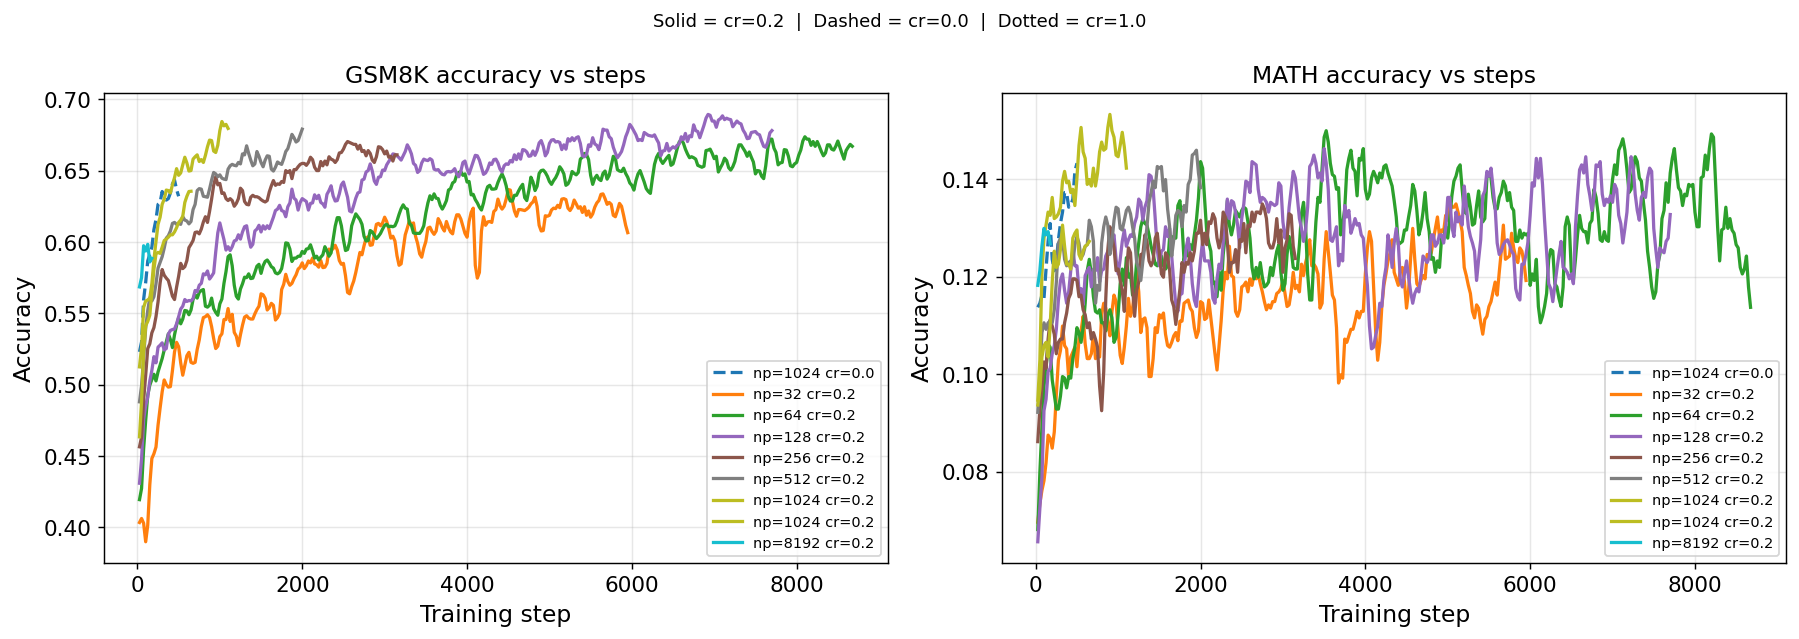

In [6]:
def smooth(s: pd.Series, w: int = 1) -> pd.Series:
    return s.rolling(window=w, min_periods=1, center=True).mean()

def batch_color_map(experiments):
    """Assign a consistent colour to each (n_prompts, clip_ratio) combination."""
    keys = sorted(
        set((m['n_prompts'], m['clip_ratio']) for m in experiments.values()),
        key=lambda x: (x[1], x[0])
    )
    cmap = plt.cm.tab10
    return {k: cmap(i / max(len(keys)-1, 1)) for i, k in enumerate(keys)}

CMAP = batch_color_map(experiments)

# ── Accuracy vs training steps ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for meta in sorted(experiments.values(), key=lambda m: (m['clip_ratio'], m.get('total_batch', 0))):
    hist = meta['history']
    color = CMAP.get((meta['n_prompts'], meta['clip_ratio']), 'grey')
    lbl   = f"np={meta['n_prompts']} cr={meta['clip_ratio']}"
    ls    = '-' if meta['clip_ratio'] == 0.2 else ('--' if meta['clip_ratio'] == 0.0 else ':')
    for ax, col, title in [
        (axes[0], GSM8K_COL, 'GSM8K accuracy'),
        (axes[1], MATH_COL,  'MATH accuracy'),
    ]:
        df = hist[[STEP_COL, col]].dropna().sort_values(STEP_COL)
        if df.empty: continue
        ax.plot(df[STEP_COL], smooth(df[col], 3), color=color, ls=ls, label=lbl)

for ax, title in [(axes[0], 'GSM8K accuracy vs steps'), (axes[1], 'MATH accuracy vs steps')]:
    ax.set_xlabel('Training step'); ax.set_ylabel('Accuracy')
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.suptitle('Solid = cr=0.2  |  Dashed = cr=0.0  |  Dotted = cr=1.0', fontsize=10)
plt.tight_layout()
plt.savefig('fig_accuracy_vs_steps.pdf', bbox_inches='tight')
plt.show()

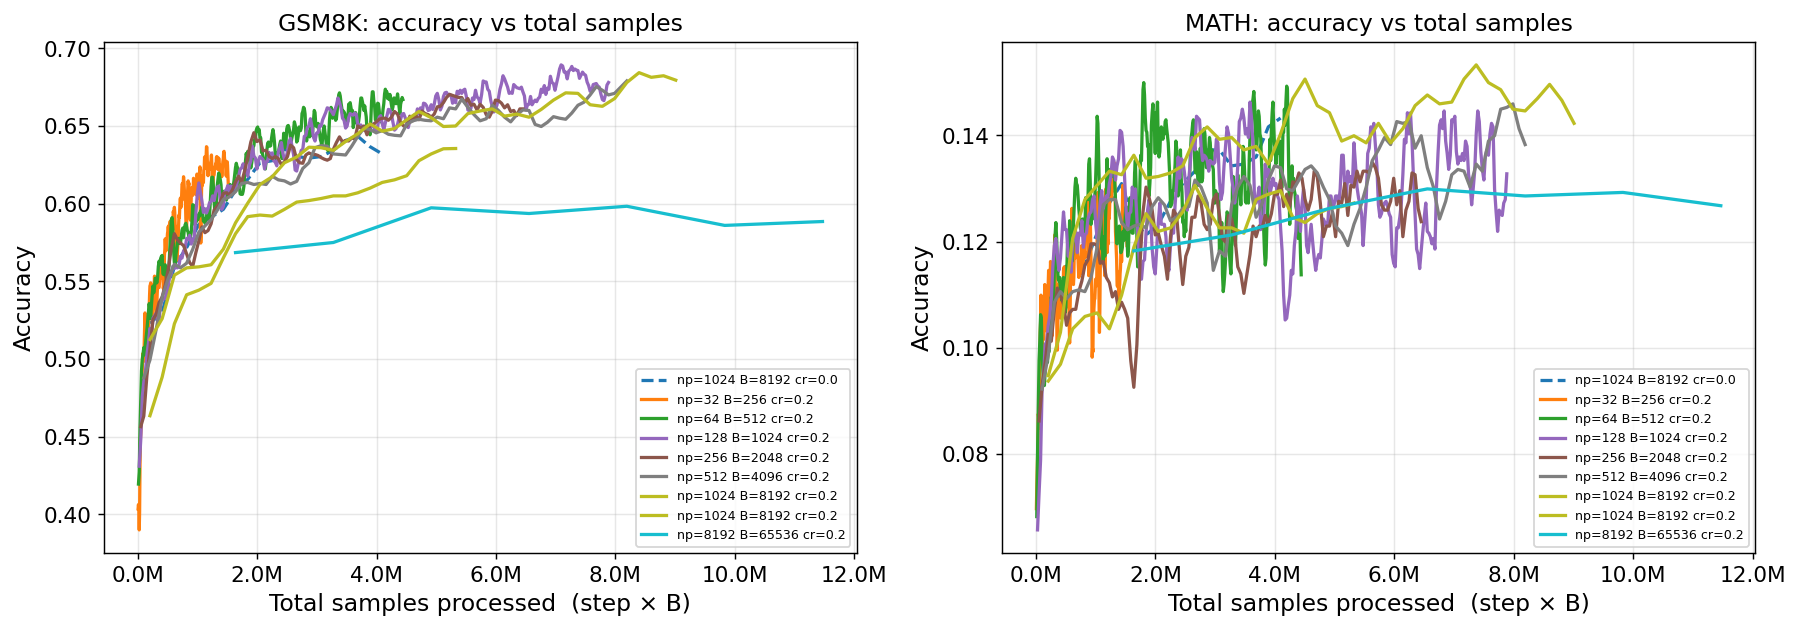

In [7]:
# ── Accuracy vs total *samples* (compute efficiency view) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for meta in sorted(experiments.values(), key=lambda m: (m['clip_ratio'], m.get('total_batch', 0))):
    hist  = meta['history']
    B     = meta.get('total_batch', 1)
    color = CMAP.get((meta['n_prompts'], meta['clip_ratio']), 'grey')
    lbl   = f"np={meta['n_prompts']} B={B} cr={meta['clip_ratio']}"
    ls    = '-' if meta['clip_ratio'] == 0.2 else ('--' if meta['clip_ratio'] == 0.0 else ':')
    for ax, col in [(axes[0], GSM8K_COL), (axes[1], MATH_COL)]:
        df = hist[[STEP_COL, col]].dropna().sort_values(STEP_COL)
        if df.empty: continue
        ax.plot(df[STEP_COL]*B, smooth(df[col], 3), color=color, ls=ls, label=lbl)

for ax, title in [(axes[0], 'GSM8K: accuracy vs total samples'),
                  (axes[1], 'MATH: accuracy vs total samples')]:
    ax.set_xlabel('Total samples processed  (step × B)')
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.legend(fontsize=7)
    ax.grid(alpha=.3)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('fig_accuracy_vs_samples.pdf', bbox_inches='tight')
plt.show()

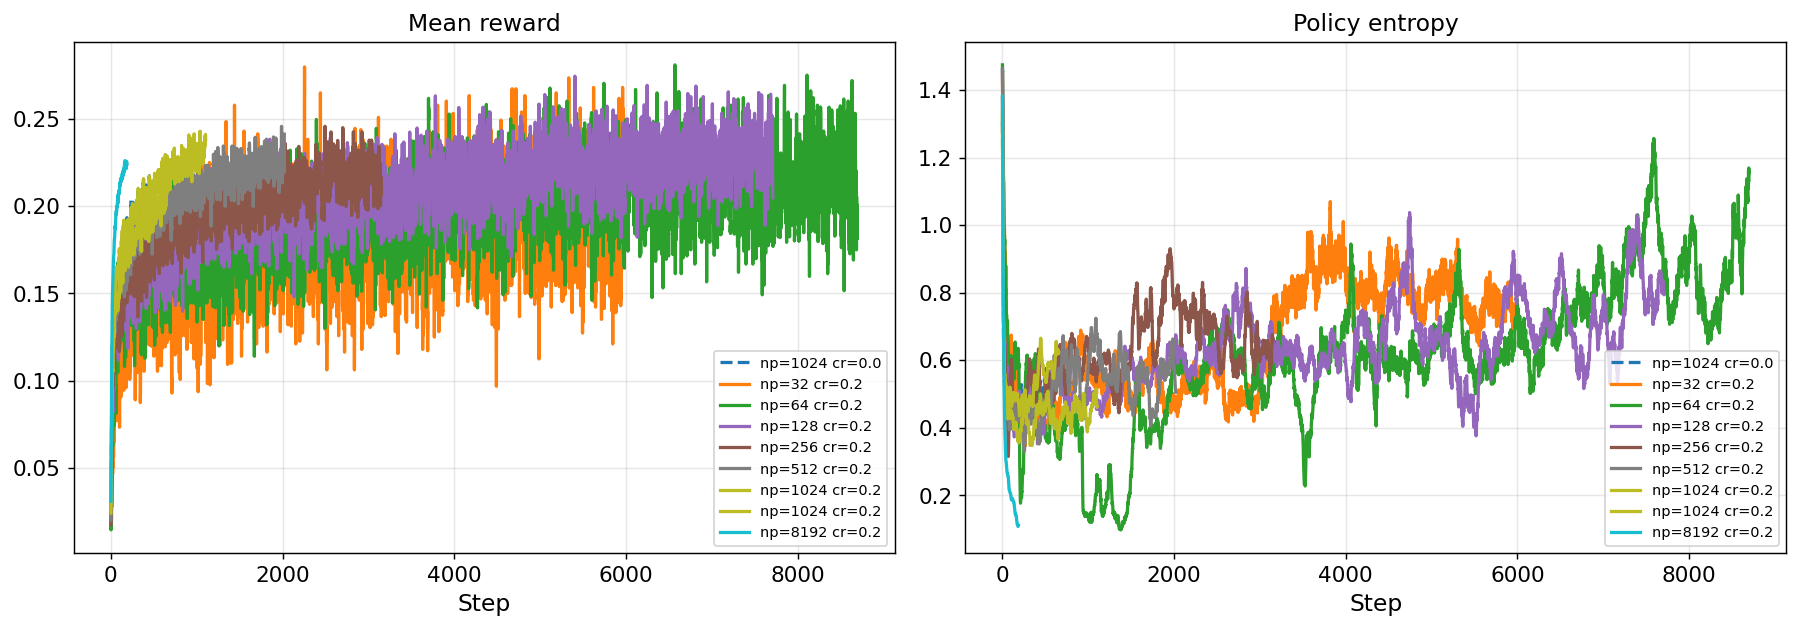

In [8]:
# ── Reward mean and policy entropy ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for meta in sorted(experiments.values(), key=lambda m: (m['clip_ratio'], m.get('total_batch', 0))):
    hist  = meta['history']
    color = CMAP.get((meta['n_prompts'], meta['clip_ratio']), 'grey')
    lbl   = f"np={meta['n_prompts']} cr={meta['clip_ratio']}"
    ls    = '-' if meta['clip_ratio'] == 0.2 else ('--' if meta['clip_ratio'] == 0.0 else ':')
    for ax, col, title in [
        (axes[0], REWARD_COL, 'Mean reward over training'),
        (axes[1], ENTROPY_COL,'Policy entropy over training'),
    ]:
        df = hist[[STEP_COL, col]].dropna().sort_values(STEP_COL)
        if df.empty: continue
        ax.plot(df[STEP_COL], smooth(df[col], 5), color=color, ls=ls, label=lbl)

for ax, title in [(axes[0], 'Mean reward'), (axes[1], 'Policy entropy')]:
    ax.set_xlabel('Step'); ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig('fig_reward_entropy.pdf', bbox_inches='tight')
plt.show()

## 4. Policy ratio & KL analysis

These are the **core algorithmic diagnostics** for understanding what limits RLVR efficiency:

* **`pg_clipfrac`** — fraction of token-level IS ratios that hit the PPO clip bound.  With `ppo_epochs=1` this should stay low and roughly constant.  A high clip fraction signals that the policy is drifting far from the rollout distribution.
* **`ppo_kl`** — token-averaged KL divergence between the current policy and the rollout policy.  Should be small under on-policy GRPO.

Looking at how these vary with `n_prompts` (batch size) tells us whether the gradient noise regime or the ratio-drift regime dominates.

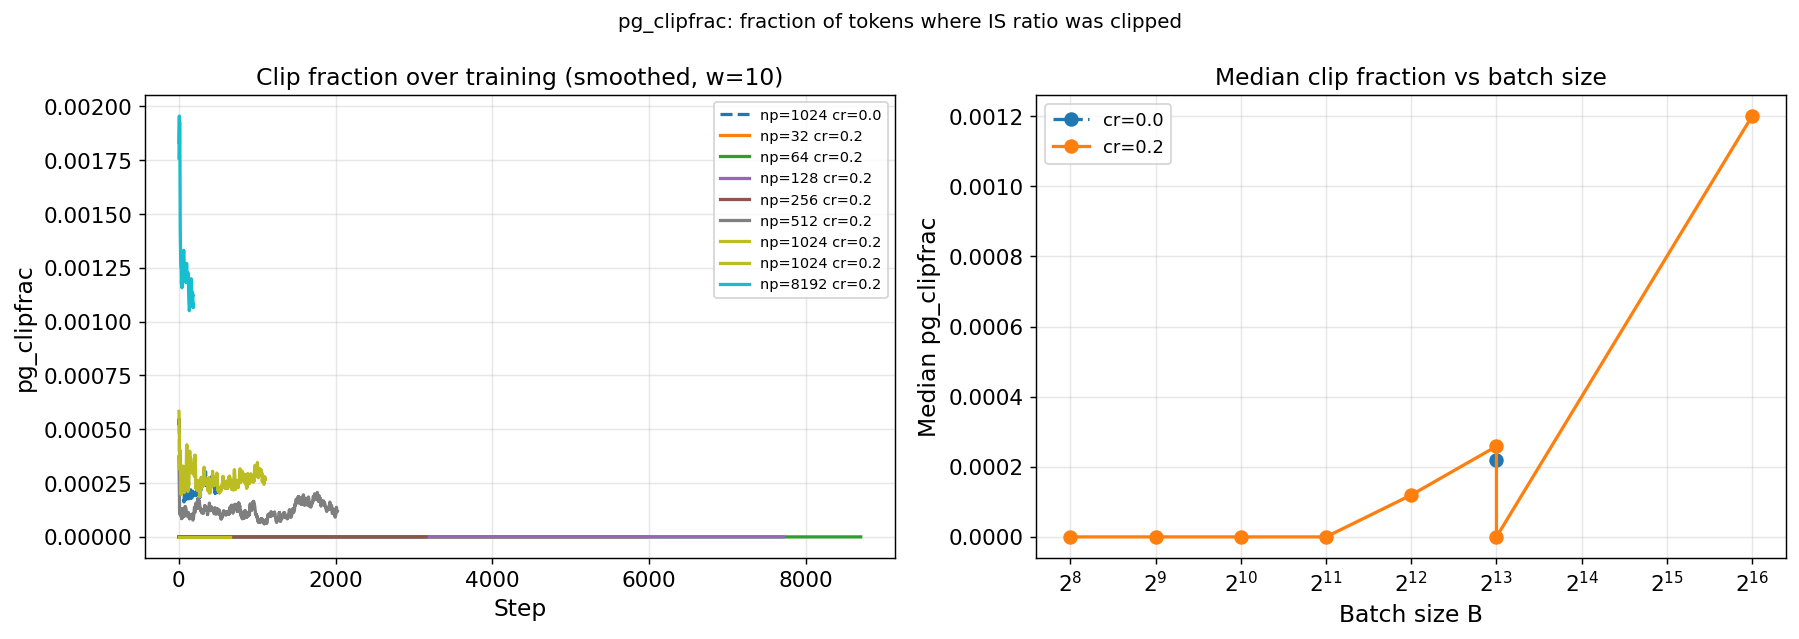


Clip fraction summary:
    B   np  cr     mean      med      p90
 8192 1024 0.0 0.000232 0.000219 0.000296
  256   32 0.2 0.000000 0.000000 0.000000
  512   64 0.2 0.000000 0.000000 0.000000
 1024  128 0.2 0.000000 0.000000 0.000000
 2048  256 0.2 0.000000 0.000000 0.000000
 4096  512 0.2 0.000124 0.000120 0.000175
 8192 1024 0.2 0.000269 0.000258 0.000345
 8192 1024 0.2 0.000000 0.000000 0.000000
65536 8192 0.2 0.001246 0.001200 0.001376


In [9]:
# ── pg_clipfrac over training ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw timeseries  |  Right: boxplot summary per experiment
clip_summaries = []   # for the scatter plot later
for meta in sorted(experiments.values(), key=lambda m: (m['clip_ratio'], m.get('total_batch', 0))):
    hist  = meta['history']
    if CLIPFRAC_COL not in hist.columns: continue
    df = hist[[STEP_COL, CLIPFRAC_COL]].dropna().sort_values(STEP_COL)
    if df.empty: continue

    color = CMAP.get((meta['n_prompts'], meta['clip_ratio']), 'grey')
    lbl   = f"np={meta['n_prompts']} cr={meta['clip_ratio']}"
    ls    = '-' if meta['clip_ratio'] == 0.2 else ('--' if meta['clip_ratio'] == 0.0 else ':')

    axes[0].plot(df[STEP_COL], smooth(df[CLIPFRAC_COL], 10), color=color, ls=ls, label=lbl)
    clip_summaries.append({
        'B':    meta.get('total_batch'),
        'np':   meta['n_prompts'],
        'cr':   meta['clip_ratio'],
        'mean': df[CLIPFRAC_COL].mean(),
        'med':  df[CLIPFRAC_COL].median(),
        'p90':  df[CLIPFRAC_COL].quantile(.9),
    })

axes[0].set_xlabel('Step'); axes[0].set_ylabel('pg_clipfrac')
axes[0].set_title('Clip fraction over training (smoothed, w=10)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)

# Right: median clip fraction vs batch size (one dot per experiment)
cs = pd.DataFrame(clip_summaries)
if not cs.empty:
    for cr_val, grp in cs.groupby('cr'):
        grp = grp.sort_values('B')
        ls = '-' if cr_val == 0.2 else ('--' if cr_val == 0.0 else ':')
        axes[1].plot(grp['B'], grp['med'], 'o-', ls=ls, label=f'cr={cr_val}', ms=7)
axes[1].set_xscale('log', base=2)
axes[1].set_xlabel('Batch size B'); axes[1].set_ylabel('Median pg_clipfrac')
axes[1].set_title('Median clip fraction vs batch size')
axes[1].legend(); axes[1].grid(alpha=.3)

plt.suptitle('pg_clipfrac: fraction of tokens where IS ratio was clipped', fontsize=11)
plt.tight_layout()
plt.savefig('fig_clipfrac.pdf', bbox_inches='tight')
plt.show()

if not cs.empty:
    print('\nClip fraction summary:')
    print(cs.sort_values(['cr','B']).to_string(index=False))

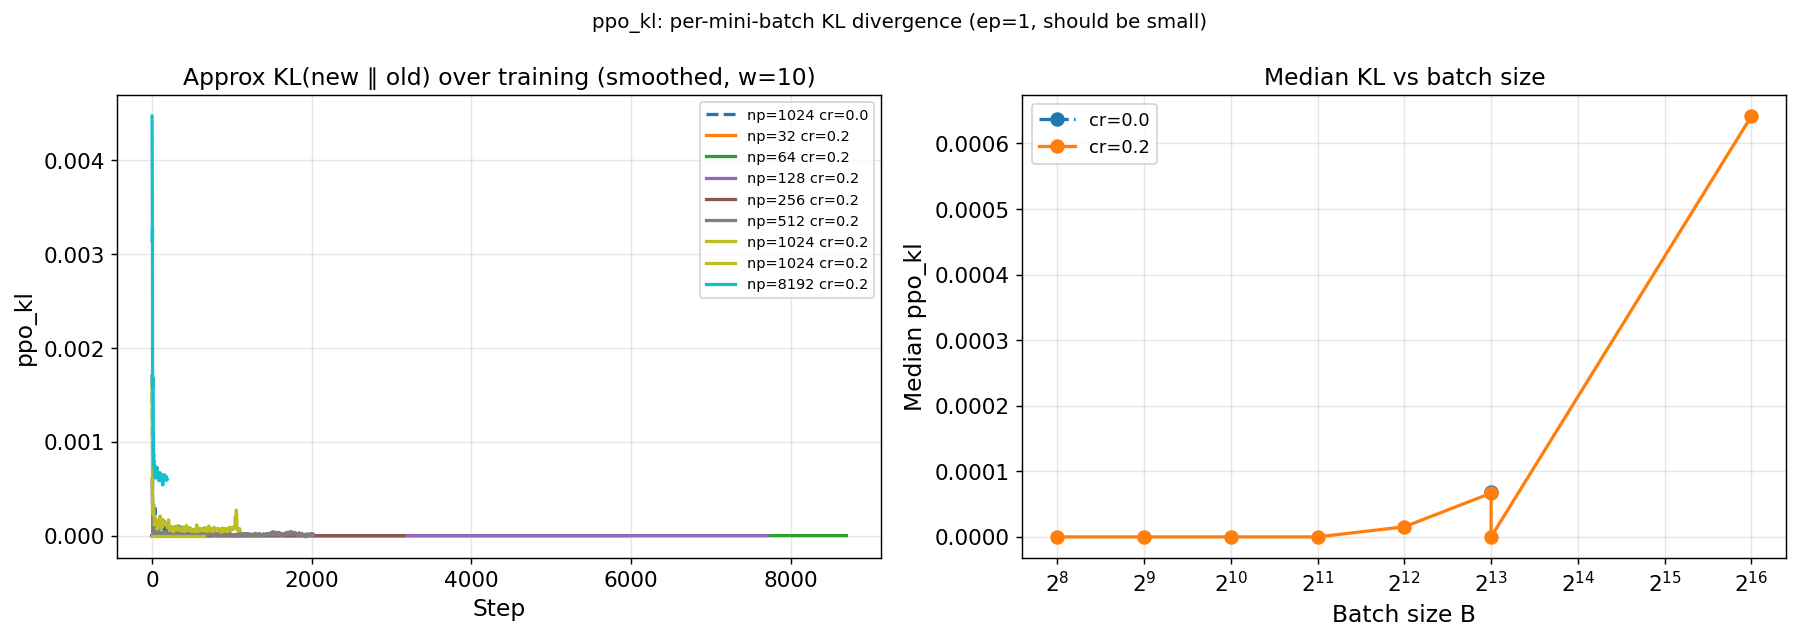

In [10]:
# ── ppo_kl over training ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

kl_summaries = []
for meta in sorted(experiments.values(), key=lambda m: (m['clip_ratio'], m.get('total_batch', 0))):
    hist  = meta['history']
    if KL_COL not in hist.columns: continue
    df = hist[[STEP_COL, KL_COL]].dropna().sort_values(STEP_COL)
    if df.empty: continue

    color = CMAP.get((meta['n_prompts'], meta['clip_ratio']), 'grey')
    lbl   = f"np={meta['n_prompts']} cr={meta['clip_ratio']}"
    ls    = '-' if meta['clip_ratio'] == 0.2 else ('--' if meta['clip_ratio'] == 0.0 else ':')

    axes[0].plot(df[STEP_COL], smooth(df[KL_COL], 10), color=color, ls=ls, label=lbl)
    kl_summaries.append({
        'B':  meta.get('total_batch'),
        'np': meta['n_prompts'],
        'cr': meta['clip_ratio'],
        'mean': df[KL_COL].mean(),
        'med':  df[KL_COL].median(),
    })

axes[0].set_xlabel('Step'); axes[0].set_ylabel('ppo_kl')
axes[0].set_title('Approx KL(new ∥ old) over training (smoothed, w=10)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)

kls = pd.DataFrame(kl_summaries)
if not kls.empty:
    for cr_val, grp in kls.groupby('cr'):
        grp = grp.sort_values('B')
        ls = '-' if cr_val == 0.2 else ('--' if cr_val == 0.0 else ':')
        axes[1].plot(grp['B'], grp['med'], 'o-', ls=ls, label=f'cr={cr_val}', ms=7)
axes[1].set_xscale('log', base=2)
axes[1].set_xlabel('Batch size B'); axes[1].set_ylabel('Median ppo_kl')
axes[1].set_title('Median KL vs batch size')
axes[1].legend(); axes[1].grid(alpha=.3)

plt.suptitle('ppo_kl: per-mini-batch KL divergence (ep=1, should be small)', fontsize=11)
plt.tight_layout()
plt.savefig('fig_ppo_kl.pdf', bbox_inches='tight')
plt.show()

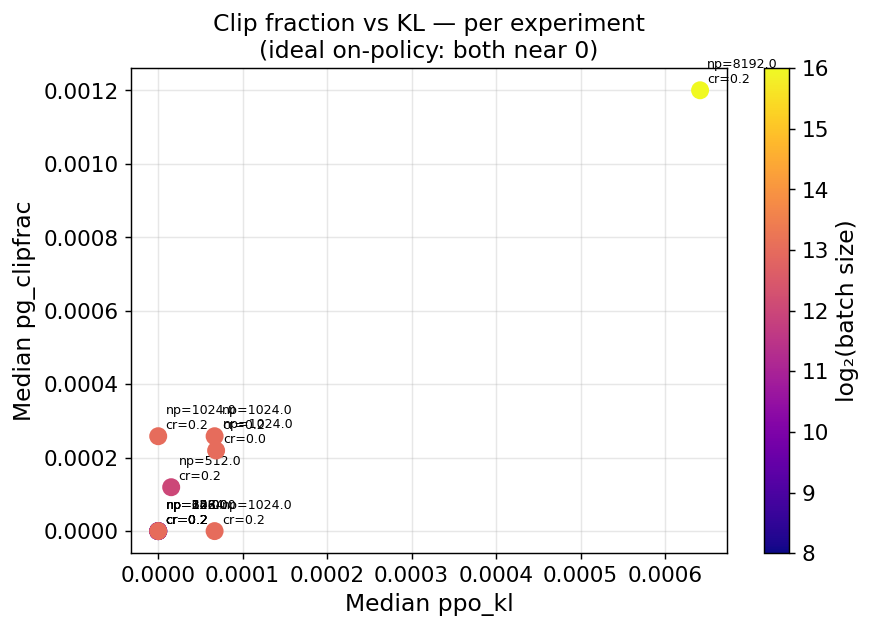

In [11]:
# ── Joint scatter: clipfrac vs KL coloured by batch size ─────────────────
if not cs.empty and not kls.empty:
    merged = cs.merge(kls, on=['B','np','cr'], suffixes=('_cf','_kl'))
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(merged['med_kl'], merged['med_cf'],
                    c=np.log2(merged['B'].clip(lower=1)),
                    s=80, cmap='plasma', zorder=5)
    for _, r in merged.iterrows():
        ax.annotate(f"np={r['np']}\ncr={r['cr']}",
                    (r['med_kl'], r['med_cf']), fontsize=7,
                    xytext=(4, 4), textcoords='offset points')
    plt.colorbar(sc, ax=ax, label='log₂(batch size)')
    ax.set_xlabel('Median ppo_kl'); ax.set_ylabel('Median pg_clipfrac')
    ax.set_title('Clip fraction vs KL — per experiment\n(ideal on-policy: both near 0)')
    ax.grid(alpha=.3)
    plt.tight_layout()
    plt.savefig('fig_clipfrac_vs_kl.pdf', bbox_inches='tight')
    plt.show()

## 5. Gradient statistics

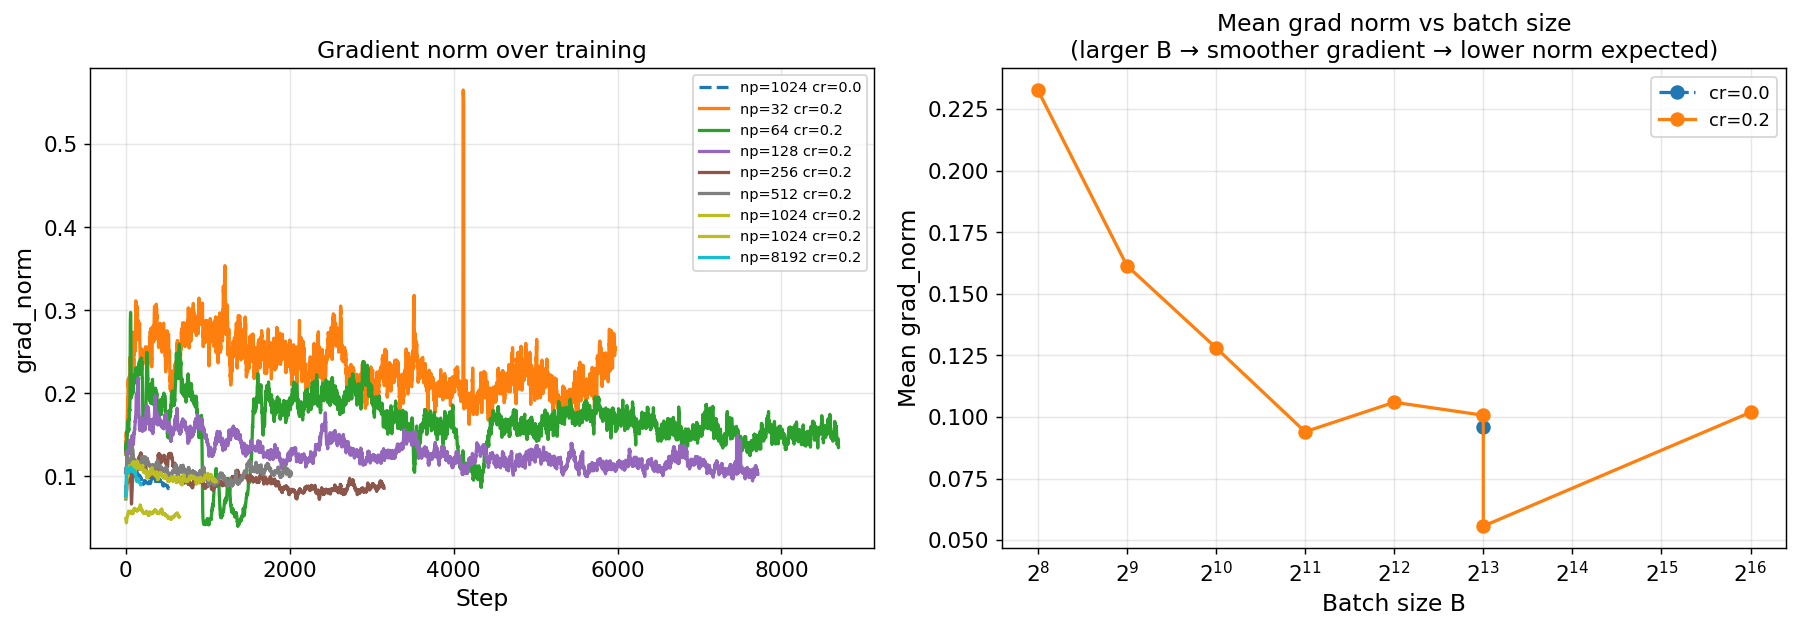

In [12]:
# ── Gradient norm over training ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gn_summaries = []
for meta in sorted(experiments.values(), key=lambda m: (m['clip_ratio'], m.get('total_batch', 0))):
    hist  = meta['history']
    if GRADNORM_COL not in hist.columns: continue
    df = hist[[STEP_COL, GRADNORM_COL]].dropna().sort_values(STEP_COL)
    if df.empty: continue

    color = CMAP.get((meta['n_prompts'], meta['clip_ratio']), 'grey')
    lbl   = f"np={meta['n_prompts']} cr={meta['clip_ratio']}"
    ls    = '-' if meta['clip_ratio'] == 0.2 else ('--' if meta['clip_ratio'] == 0.0 else ':')
    axes[0].plot(df[STEP_COL], smooth(df[GRADNORM_COL], 10), color=color, ls=ls, label=lbl)
    gn_summaries.append({'B': meta.get('total_batch'), 'np': meta['n_prompts'],
                         'cr': meta['clip_ratio'], 'mean': df[GRADNORM_COL].mean()})

axes[0].set_xlabel('Step'); axes[0].set_ylabel('grad_norm')
axes[0].set_title('Gradient norm over training')
axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)

gns = pd.DataFrame(gn_summaries)
if not gns.empty:
    for cr_val, grp in gns.groupby('cr'):
        grp = grp.sort_values('B')
        axes[1].plot(grp['B'], grp['mean'], 'o-',
                     ls=('-' if cr_val==0.2 else '--'), label=f'cr={cr_val}', ms=7)
axes[1].set_xscale('log', base=2)
axes[1].set_xlabel('Batch size B'); axes[1].set_ylabel('Mean grad_norm')
axes[1].set_title('Mean grad norm vs batch size\n(larger B → smoother gradient → lower norm expected)')
axes[1].legend(); axes[1].grid(alpha=.3)

plt.tight_layout()
plt.savefig('fig_gradnorm.pdf', bbox_inches='tight')
plt.show()

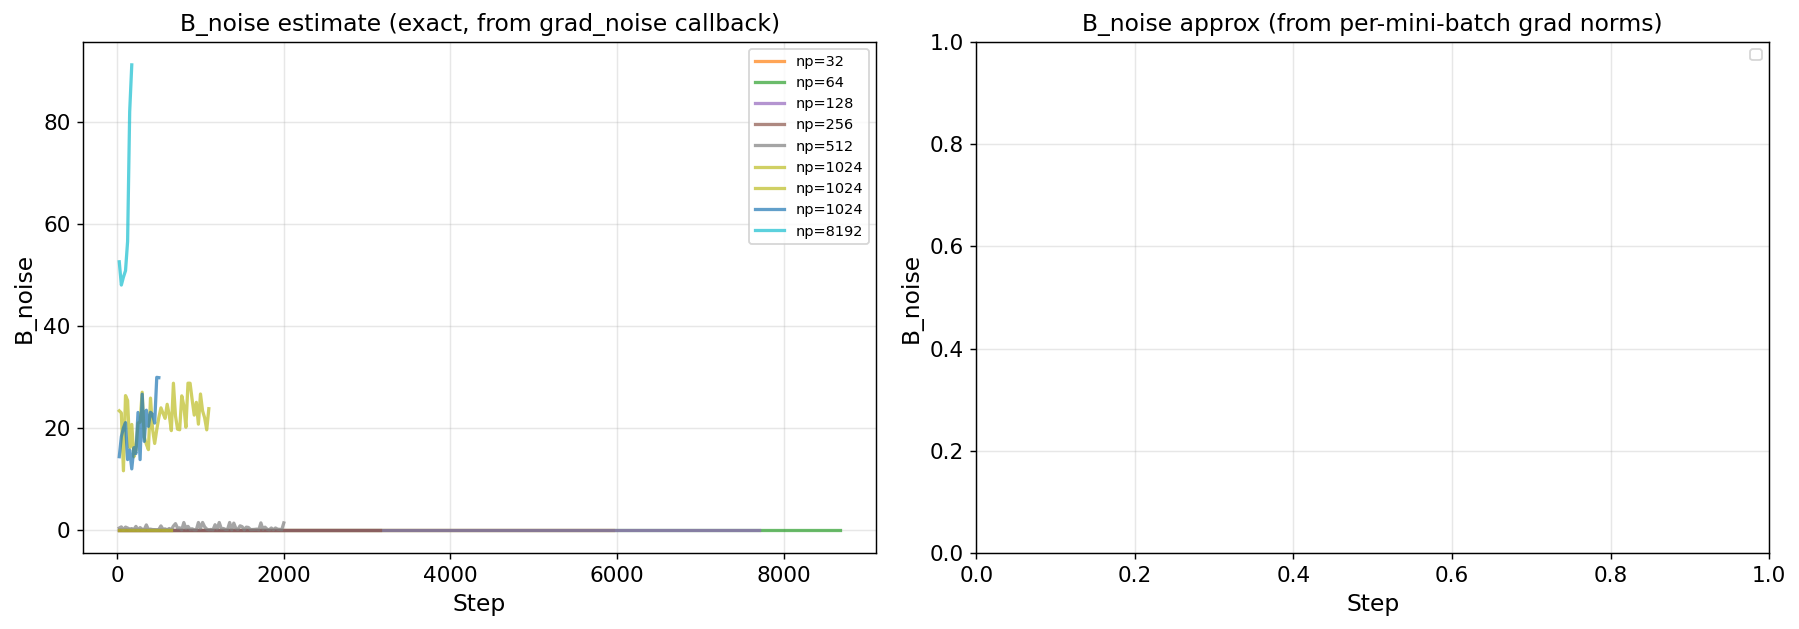

In [13]:
# ── B_noise estimates ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
has_noise = False

for meta in sorted(experiments.values(), key=lambda m: m.get('total_batch', 0)):
    hist  = meta['history']
    color = CMAP.get((meta['n_prompts'], meta['clip_ratio']), 'grey')
    lbl   = f"np={meta['n_prompts']}"

    for ax, col in [(axes[0], BNOISE_COL), (axes[1], BNOISE_APX)]:
        if col not in hist.columns: continue
        df = hist[[STEP_COL, col]].dropna().sort_values(STEP_COL)
        if df.empty: continue
        # Clip extreme outliers for readability
        vals = df[col].clip(upper=df[col].quantile(.95))
        ax.plot(df[STEP_COL], vals, color=color, alpha=.7, label=lbl)
        has_noise = True

for ax, title in [
    (axes[0], 'B_noise estimate (exact, from grad_noise callback)'),
    (axes[1], 'B_noise approx (from per-mini-batch grad norms)'),
]:
    ax.set_xlabel('Step'); ax.set_ylabel('B_noise')
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=.3)

if not has_noise:
    print('No B_noise data logged yet — enable grad_noise_measure_freq in training config.')
    plt.close()
else:
    plt.tight_layout()
    plt.savefig('fig_bnoise.pdf', bbox_inches='tight')
    plt.show()

## 6. CBS measurement — S(B), E(B), McCandlish fit

**S(B)**: training steps to reach a target accuracy at batch size B.  
**E(B) = B · S(B)**: total examples processed.  
McCandlish model: `S(B) = S_min · (1 + B_noise/B)`.  The critical batch size B* ≈ B_noise.

In [14]:
def steps_to_threshold(hist: pd.DataFrame, col: str, thr: float) -> float | None:
    df = hist[[STEP_COL, col]].dropna().sort_values(STEP_COL)
    above = df[df[col] >= thr]
    return float(above[STEP_COL].iloc[0]) if len(above) else None

def compute_sb(exps: dict, col: str, thresholds: list) -> pd.DataFrame:
    rows = []
    for name, meta in exps.items():
        hist = meta['history']
        if col not in hist.columns: continue
        for thr in thresholds:
            s = steps_to_threshold(hist, col, thr)
            rows.append({
                'name': name, 'n_prompts': meta['n_prompts'],
                'n_rollouts': meta['n_rollouts'], 'B': meta.get('total_batch'),
                'clip_ratio': meta['clip_ratio'], 'ppo_epochs': meta['ppo_epochs'],
                'threshold': thr, 'S_B': s,
                'E_B': s * meta['total_batch'] if s else None,
            })
    return pd.DataFrame(rows)

# Use only the standard cr=0.2 runs for the CBS curve (clean baseline)
exps_baseline = {k: v for k, v in experiments.items() if abs(v['clip_ratio'] - 0.2) < 1e-6 and v['ppo_epochs'] == 1}

gsm_thr = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
sb_gsm  = compute_sb(exps_baseline, GSM8K_COL, gsm_thr)
sb_math = compute_sb(exps_baseline, MATH_COL,  [0.06, 0.08, 0.10, 0.12, 0.14])

print('S(B) for GSM8K (cr=0.2, ep=1):')
print(sb_gsm.pivot_table(index='threshold', columns='B', values='S_B').to_string())

S(B) for GSM8K (cr=0.2, ep=1):
B           256     512     1024   2048   4096   8192   65536
threshold                                                    
0.40         50.0    25.0    25.0   25.0   25.0   25.0   25.0
0.45        175.0   100.0    50.0   50.0   25.0   37.5   25.0
0.50        325.0   175.0   150.0  100.0   75.0   62.5   25.0
0.55        825.0   475.0   525.0  200.0  125.0  125.0   50.0
0.60       2400.0  1800.0   975.0  625.0  325.0  275.0  100.0
0.65          NaN  3925.0  2750.0  975.0  925.0  450.0    NaN


In [15]:
def mccandlish_S(B, S_min, B_noise): return S_min * (1 + B_noise / B)
def mccandlish_E(B, E_min, B_noise): return E_min * (1 + B / B_noise)

def fit_mccandlish(sb_df: pd.DataFrame, thr: float):
    sub = sb_df[(sb_df['threshold'] == thr) & sb_df['S_B'].notna()].dropna(subset=['B'])
    if len(sub) < 3: return None
    B, S = sub['B'].values.astype(float), sub['S_B'].values.astype(float)
    try:
        popt, _ = curve_fit(mccandlish_S, B, S,
                            p0=[S.min(), float(B[len(B)//2])],
                            bounds=([0,0],[np.inf,np.inf]), maxfev=10000)
        S_pred = mccandlish_S(B, *popt)
        ss_res = np.sum((S - S_pred)**2)
        ss_tot = np.sum((S - S.mean())**2)
        return dict(S_min=popt[0], B_noise=popt[1],
                    R2=(1-ss_res/ss_tot if ss_tot>0 else 0),
                    B_arr=B, S_arr=S)
    except Exception:
        return None

fits = {}
for thr in gsm_thr:
    f = fit_mccandlish(sb_gsm, thr)
    if f:
        fits[thr] = f
        print(f'thr={thr:.0%}  B_noise={f["B_noise"]:.0f}  S_min={f["S_min"]:.1f}  R²={f["R2"]:.3f}')

thr=40%  B_noise=256  S_min=22.5  R²=0.772
thr=45%  B_noise=1471  S_min=25.6  R²=0.962
thr=50%  B_noise=1304  S_min=53.5  R²=0.963
thr=55%  B_noise=1601  S_min=119.3  R²=0.881
thr=60%  B_noise=2359  S_min=256.0  R²=0.950
thr=65%  B_noise=5596  S_min=344.8  R²=0.950


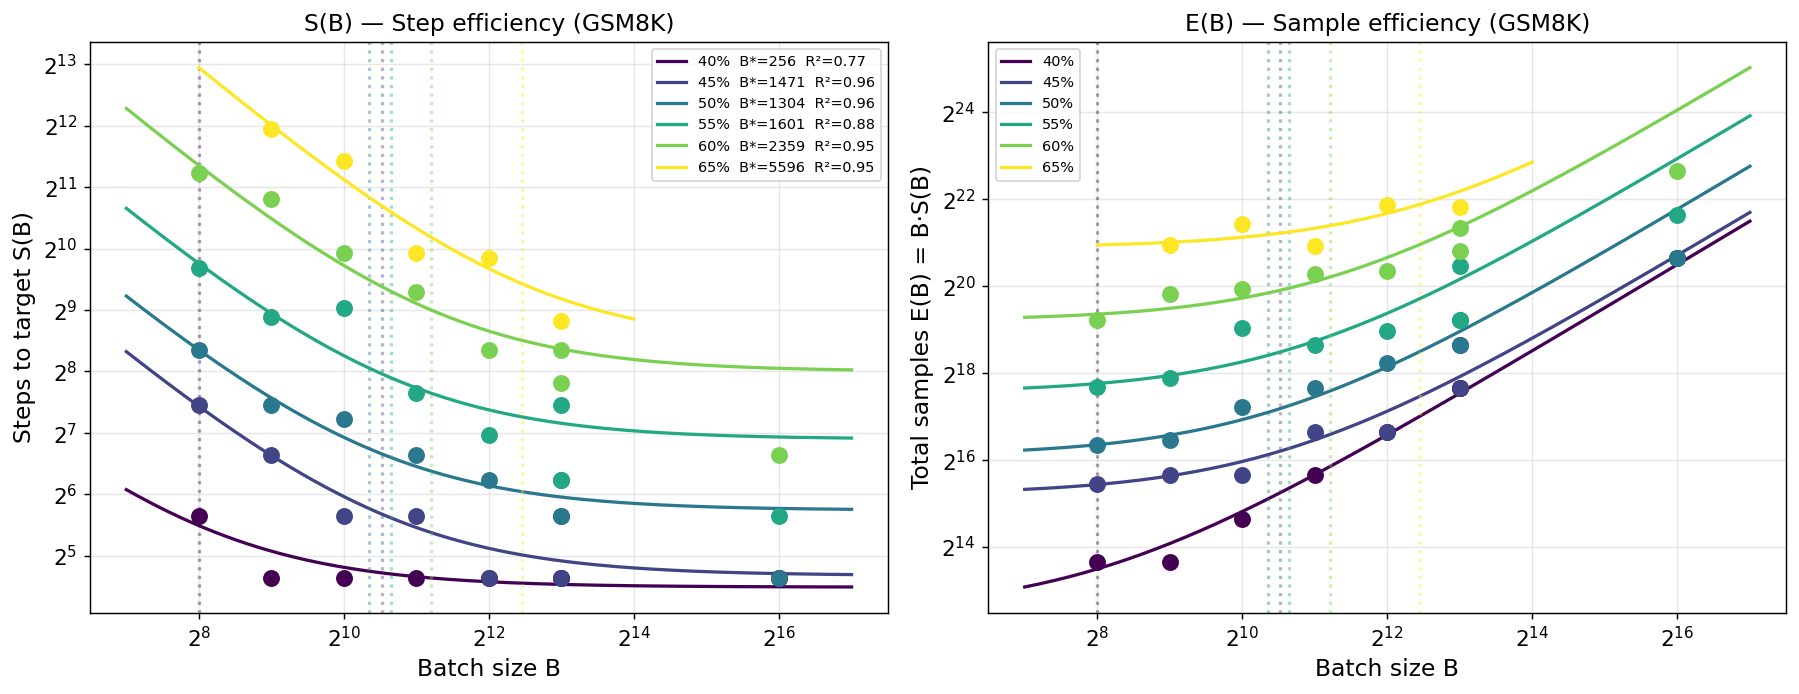

In [16]:
# ── S(B) and E(B) plots with McCandlish fits ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
cmap_t = plt.cm.viridis
thrs_w_fits = sorted(fits.keys())
tcolors = {t: cmap_t(i/max(len(thrs_w_fits)-1,1)) for i,t in enumerate(thrs_w_fits)}

for thr, fit in fits.items():
    c   = tcolors[thr]
    B   = fit['B_arr']; S = fit['S_arr']
    B_s = np.geomspace(B.min()*.5, B.max()*2, 200)

    axes[0].scatter(B, S, color=c, s=70, zorder=5)
    axes[0].plot(B_s, mccandlish_S(B_s, fit['S_min'], fit['B_noise']),
                 color=c, label=f'{thr:.0%}  B*={fit["B_noise"]:.0f}  R²={fit["R2"]:.2f}')
    axes[0].axvline(fit['B_noise'], color=c, ls=':', alpha=.4)

    E   = S * B
    E_m = fit['S_min'] * fit['B_noise']
    axes[1].scatter(B, E, color=c, s=70, zorder=5)
    axes[1].plot(B_s, mccandlish_E(B_s, E_m, fit['B_noise']), color=c, label=f'{thr:.0%}')
    axes[1].axvline(fit['B_noise'], color=c, ls=':', alpha=.4)

for ax, xlabel, ylabel, title in [
    (axes[0], 'Batch size B', 'Steps to target S(B)', 'S(B) — Step efficiency (GSM8K)'),
    (axes[1], 'Batch size B', 'Total samples E(B) = B·S(B)', 'E(B) — Sample efficiency (GSM8K)'),
]:
    ax.set_xscale('log', base=2); ax.set_yscale('log', base=2)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(alpha=.3, which='both')

plt.tight_layout()
plt.savefig('fig_sb_eb_gsm8k.pdf', bbox_inches='tight')
plt.show()

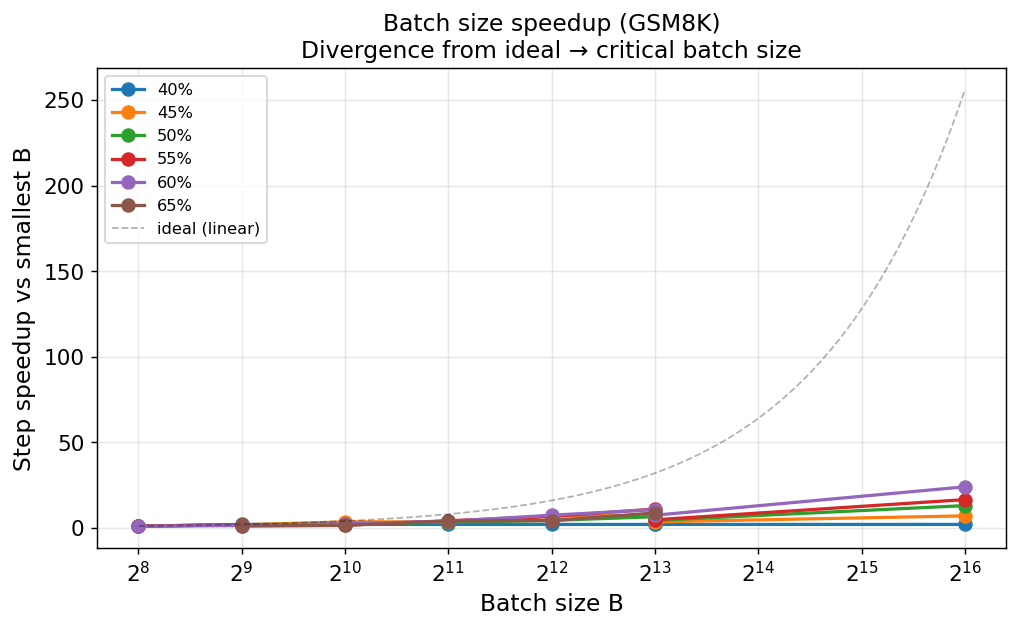

In [17]:
# ── Step speedup as a function of batch size ──────────────────────────────
# Speedup(B) = S(B_min) / S(B) — how much faster does larger B converge vs smallest batch?
# Perfect linear scaling: Speedup = B / B_min
fig, ax = plt.subplots(figsize=(8, 5))

for thr in gsm_thr:
    sub = sb_gsm[(sb_gsm['threshold'] == thr) & sb_gsm['S_B'].notna()].sort_values('B')
    if len(sub) < 2: continue
    B   = sub['B'].values.astype(float)
    S   = sub['S_B'].values.astype(float)
    speedup = S[0] / S
    ax.plot(B, speedup, 'o-', label=f'{thr:.0%}', ms=7)

# Ideal linear scaling reference
B_all = np.geomspace(sb_gsm['B'].min(), sb_gsm['B'].max(), 100)
ax.plot(B_all, B_all/sb_gsm['B'].min(), 'k--', alpha=.3, lw=1, label='ideal (linear)')

ax.set_xscale('log', base=2)
ax.set_xlabel('Batch size B')
ax.set_ylabel('Step speedup vs smallest B')
ax.set_title('Batch size speedup (GSM8K)\nDivergence from ideal → critical batch size')
ax.legend(fontsize=9); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig('fig_speedup.pdf', bbox_inches='tight')
plt.show()

## 7. Clip-ratio ablation: cr=0.0 vs cr=0.2

Phase 1b ran `np=1024` with `cr=0.0` (no clipping — pure unclipped REINFORCE-style surrogate).
Comparing to the standard `cr=0.2` at the same batch size tells us:

* Does clipping slow down learning, or does it provide a useful safety constraint?
* Does removing the clip let the policy drift more (higher KL) without benefit?

n_prompts values with non-standard clip_ratio: [1024]


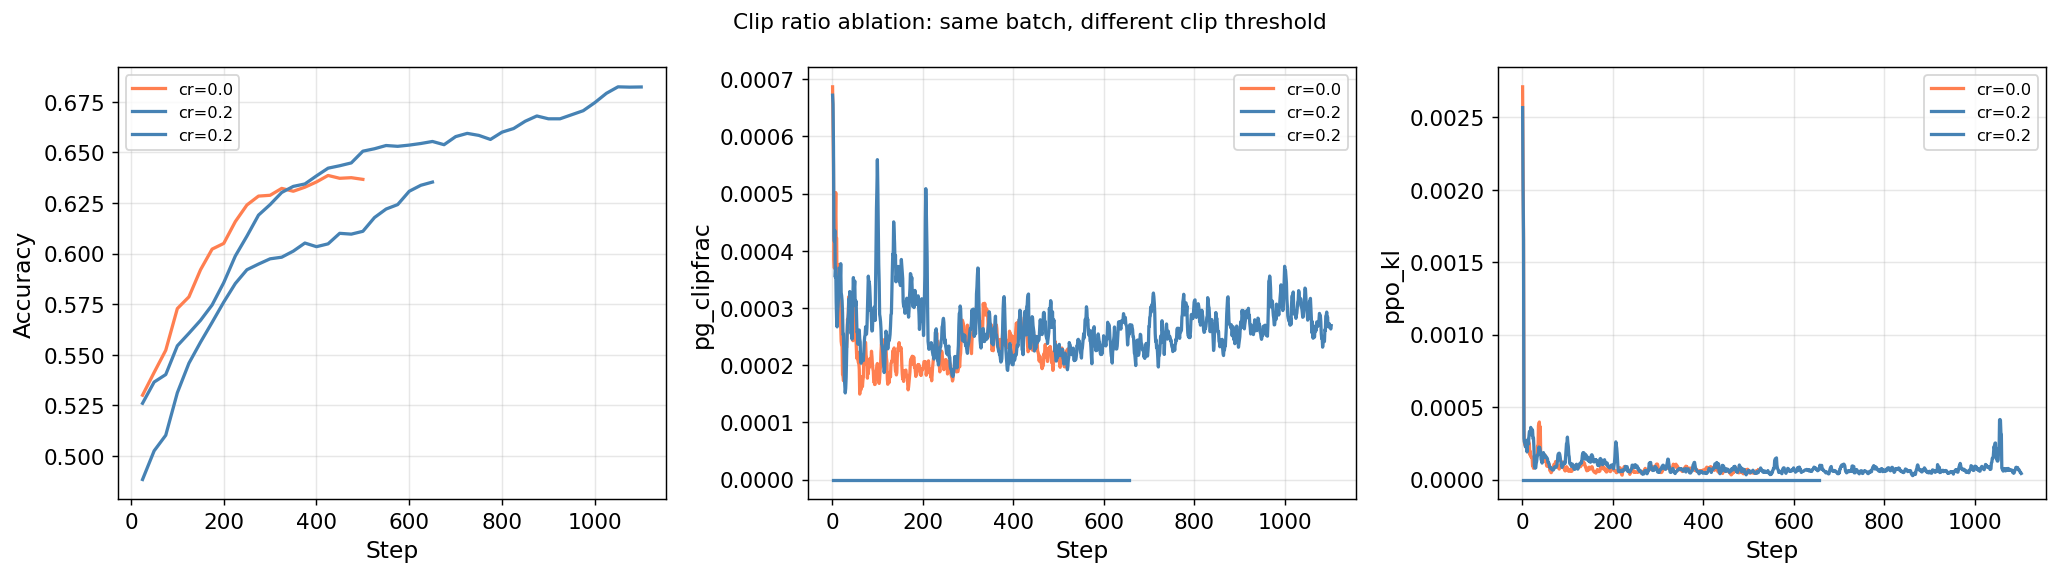

In [18]:
# Identify experiments at the same n_prompts with different clip ratios
ablation_np = sorted({m['n_prompts'] for m in experiments.values()
                      if m['clip_ratio'] != 0.2})
print(f'n_prompts values with non-standard clip_ratio: {ablation_np}')

fig, axes = plt.subplots(len(ablation_np) or 1, 3,
                          figsize=(16, 4.5 * max(len(ablation_np), 1)),
                          squeeze=False)

for row_idx, np_val in enumerate(ablation_np or [None]):
    subset = [
        m for m in experiments.values()
        if (np_val is None or m['n_prompts'] == np_val) and m['ppo_epochs'] == 1
    ]
    subset.sort(key=lambda m: m['clip_ratio'])

    for meta in subset:
        hist  = meta['history']
        color = 'steelblue' if abs(meta['clip_ratio'] - 0.2) < 1e-6 else \
                'coral'    if abs(meta['clip_ratio'] - 0.0) < 1e-6 else 'green'
        lbl   = f"cr={meta['clip_ratio']}"

        for ax, col, title in [
            (axes[row_idx][0], GSM8K_COL,   f'GSM8K  np={np_val}'),
            (axes[row_idx][1], CLIPFRAC_COL, f'pg_clipfrac  np={np_val}'),
            (axes[row_idx][2], KL_COL,       f'ppo_kl  np={np_val}'),
        ]:
            df = hist[[STEP_COL, col]].dropna().sort_values(STEP_COL)
            if df.empty: continue
            axes[row_idx][0 if col==GSM8K_COL else (1 if col==CLIPFRAC_COL else 2)].plot(
                df[STEP_COL], smooth(df[col], 5), color=color, label=lbl)

    for ax_idx, (ax, ylabel) in enumerate(zip(axes[row_idx],
                                               ['Accuracy','pg_clipfrac','ppo_kl'])):
        ax.set_xlabel('Step'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=9); ax.grid(alpha=.3)

if not ablation_np:
    plt.close()
    print('No clip_ratio ablation data found yet.')
else:
    plt.suptitle('Clip ratio ablation: same batch, different clip threshold', fontsize=12)
    plt.tight_layout()
    plt.savefig('fig_clip_ratio_ablation.pdf', bbox_inches='tight')
    plt.show()

## 8. Summary

### Key findings to look for:

| Question | What to look at | Expected signal |
|---|---|---|
| Q1: Does RLVR have a CBS? | S(B) curve shape | Sub-linear increase → yes; flat → no |
| Q2: Which B is step-efficient? | S(B) elbow | Step gains flatten at B ≈ B_noise |
| Q3: Which B is sample-efficient? | E(B) minimum | E(B) has a minimum near B_noise |
| Q5: Gradient noise vs clipping? | pg_clipfrac vs B | If clipfrac is flat across B at ep=1, noise dominates |
| Q5: Does removing clip help? | cr=0.0 vs cr=0.2 | If cr=0.0 diverges or matches, clip is or isn't necessary |

In [19]:
# ── Summary table ─────────────────────────────────────────────────────────
summary_rows = []
for name, meta in sorted(experiments.items(),
                          key=lambda x: (x[1]['clip_ratio'], x[1].get('total_batch',0))):
    hist = meta['history']
    def _max(c): return round(hist[c].dropna().max(),3) if c in hist.columns and not hist[c].dropna().empty else np.nan
    def _med(c): return round(hist[c].dropna().median(),4) if c in hist.columns and not hist[c].dropna().empty else np.nan

    row = {
        'np': meta['n_prompts'], 'nr': meta['n_rollouts'],
        'B': meta.get('total_batch'), 'cr': meta['clip_ratio'],
        'ep': meta['ppo_epochs'],
        'steps': int(hist[STEP_COL].dropna().max()) if STEP_COL in hist.columns else 0,
        'gsm8k_best': _max(GSM8K_COL),
        'math_best':  _max(MATH_COL),
        'med_clipfrac': _med(CLIPFRAC_COL),
        'med_kl':       _med(KL_COL),
        'mean_gradnorm':_med(GRADNORM_COL),
    }

    # add CBS estimates at key thresholds
    for thr in [0.5, 0.6]:
        s = steps_to_threshold(hist, GSM8K_COL, thr) if GSM8K_COL in hist.columns else None
        row[f'S(B)_gsm{int(thr*100)}'] = int(s) if s else None

    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))

  np  nr     B  cr  ep  steps  gsm8k_best  math_best  med_clipfrac  med_kl  mean_gradnorm  S(B)_gsm50  S(B)_gsm60
1024   8  8192 0.0   1    522       0.646      0.151        0.0002  0.0001         0.0958          50         200
  32   8   256 0.2   1   5968       0.645      0.140        0.0000  0.0000         0.2299         325        2400
  64   8   512 0.2   1   8696       0.686      0.157        0.0000  0.0000         0.1642         175        1800
 128   8  1024 0.2   1   7710       0.694      0.153        0.0000  0.0000         0.1251         150         975
 256   8  2048 0.2   1   3152       0.674      0.143        0.0000  0.0000         0.0920         100         625
 512   8  4096 0.2   1   2020       0.683      0.149        0.0001  0.0000         0.1058          75         325
1024   8  8192 0.2   1   1103       0.688      0.156        0.0003  0.0001         0.0998          50         225
1024   8  8192 0.2   1    655       0.639      0.137        0.0000  0.0000         0.055

In [20]:
# ── McCandlish fit summary ────────────────────────────────────────────────
if fits:
    fit_rows = []
    for thr, f in sorted(fits.items()):
        fit_rows.append({
            'threshold': f'{thr:.0%}',
            'B_noise (B*)': round(f['B_noise']),
            'S_min': round(f['S_min'], 1),
            'R²': round(f['R2'], 4),
            'n_points': len(f['B_arr']),
        })
    print('McCandlish model fits (GSM8K, cr=0.2, ep=1):')
    print(pd.DataFrame(fit_rows).to_string(index=False))
    print('\nInterpretation:')
    print('  B* ≈ B_noise is the critical batch size.')
    print('  For B << B*, doubling B halves the steps → in the gradient-noise-limited regime.')
    print('  For B >> B*, doubling B barely helps → diminishing returns.')
else:
    print('Not enough data to fit the McCandlish model yet.')

McCandlish model fits (GSM8K, cr=0.2, ep=1):
threshold  B_noise (B*)  S_min     R²  n_points
      40%           256   22.5 0.7716         8
      45%          1471   25.6 0.9620         8
      50%          1304   53.5 0.9629         8
      55%          1601  119.3 0.8809         8
      60%          2359  256.0 0.9496         8
      65%          5596  344.8 0.9501         5

Interpretation:
  B* ≈ B_noise is the critical batch size.
  For B << B*, doubling B halves the steps → in the gradient-noise-limited regime.
  For B >> B*, doubling B barely helps → diminishing returns.
